# Day 2 — Visualisation, Preprocessing and Supervised Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tech4alltraining/aiml/blob/main/mlai-genai-internship/notebooks/02_day2_ml_basics.ipynb)

**ML/AI & GenAI Internship** · Each concept: examples → 5 exercises → quiz → tasks. Every chart has a 📊 reading guide.

---

## What this notebook covers

Five concepts, each in the same shape: **📘 Examples → ✏️ 5 exercises → 🧠 Quiz → 🎯 Tasks.**

| # | Concept |
|---|---|
| 1 | Visualisation — and how to *read* each chart |
| 2 | Preprocessing (and data leakage) |
| 3 | Regression: predicting a number |
| 4 | Classification: predicting a category |
| 5 | Reading metrics honestly |

**Every chart in this notebook is followed by a 📊 "How to read this chart" table.** Drawing a chart is easy; reading one is the skill.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")     # nicer defaults for every chart below
BASE = "https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/"

df = pd.read_csv(BASE + "regression/cardekho_dataset.csv")
print("Loaded", df.shape[0], "cars")
df.head(3)

Loaded 15411 cars


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.7,796,46.3,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.9,1197,82.0,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.0,1197,80.0,5,215000


---

# Concept 1 — Visualisation, and how to read a chart

🧠 **Analogy: charts are camera lenses.** You do not pick a lens because it looks nice — you pick it for what you are photographing.

**If you cannot say what question your chart answers, delete it.**

| Your question | Chart |
|---|---|
| How is one numeric column spread out? | Histogram |
| Are there outliers? | Box plot |
| Do two numeric columns move together? | Scatter plot |
| How do categories compare on average? | Bar plot |
| How many rows in each category? | Count plot |
| Which columns relate to which? | Heatmap |

## 📘 Examples

### Example 1 — Histogram: where does the data sit?

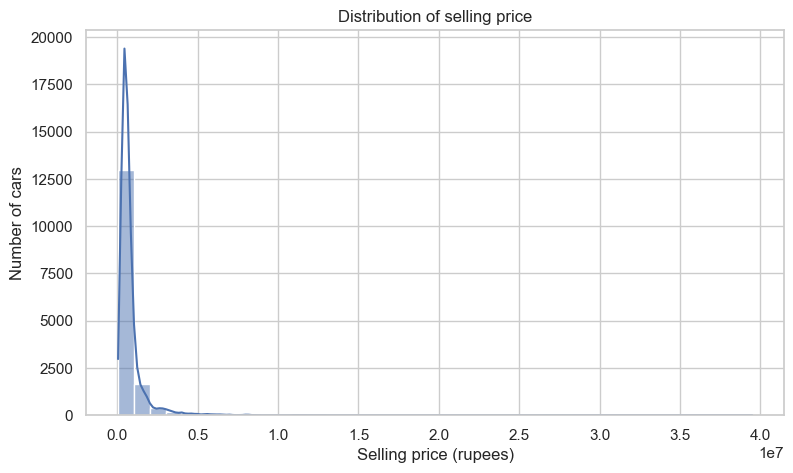

In [2]:
plt.figure(figsize=(9, 5))
sns.histplot(df["selling_price"], bins=40, kde=True)
plt.title("Distribution of selling price")
plt.xlabel("Selling price (rupees)")
plt.ylabel("Number of cars")
plt.show()

### 📊 How to read this chart — Histogram

| What you are looking at | What it means |
|---|---|
| **The x-axis** | The value being measured — here, price in rupees |
| **The y-axis** | How many rows fall in that price range. Taller bar = more cars |
| **Each bar (a 'bin')** | A price range. 40 bins means the price range was cut into 40 slices |
| **The tall bars on the left** | Most cars are cheap. This is where the bulk of your data lives |
| **The long flat tail to the right** | A few very expensive cars. This shape is called **right-skewed** |
| **The smooth curve (kde)** | A smoothed version of the bars — easier to see the overall shape |

> **In one sentence:** Most cars sell under about ₹10 lakh, but a long tail runs up to ₹40 lakh — so the *average* price will be higher than the *typical* price.

> ⚠️ **Why skew matters for modelling.** A linear regression fitted to right-skewed data gets pulled towards those few expensive cars, making it worse at predicting the many cheap ones. Spotting skew in a histogram tells you to consider a log transform *before* you waste time on a poor model.

**🔁 Change one thing:** set `bins=5`, then `bins=200`. With 5 the shape disappears; with 200 it becomes noise. **The number of bins is a choice you make, and it changes the story your chart tells.**

### Example 2 — Box plot: where are the outliers?

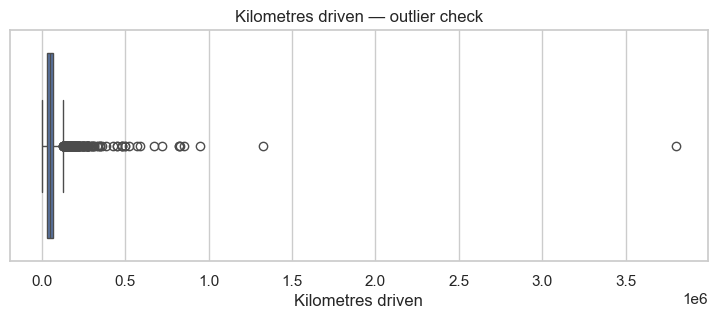

Q1 (25%)      :       30,000
Median (50%)  :       50,000
Q3 (75%)      :       70,000
IQR (Q3 - Q1) :       40,000
Upper fence   :      130,000   <- dots beyond this are flagged
Actual max    :    3,800,000


In [3]:
plt.figure(figsize=(9, 3))
sns.boxplot(x=df["km_driven"])
plt.title("Kilometres driven — outlier check")
plt.xlabel("Kilometres driven")
plt.show()

# The exact numbers behind the picture
q1, median, q3 = df["km_driven"].quantile([0.25, 0.5, 0.75])
iqr = q3 - q1
print(f"Q1 (25%)      : {q1:>12,.0f}")
print(f"Median (50%)  : {median:>12,.0f}")
print(f"Q3 (75%)      : {q3:>12,.0f}")
print(f"IQR (Q3 - Q1) : {iqr:>12,.0f}")
print(f"Upper fence   : {q3 + 1.5 * iqr:>12,.0f}   <- dots beyond this are flagged")
print(f"Actual max    : {df['km_driven'].max():>12,.0f}")

### 📊 How to read this chart — Box plot

| What you are looking at | What it means |
|---|---|
| **The box** | The middle 50% of the data, from the 25th to the 75th percentile |
| **The line inside the box** | The **median** — half the cars are below it, half above |
| **The left edge of the box** | Q1: 25% of cars have driven less than this |
| **The right edge of the box** | Q3: 75% of cars have driven less than this |
| **The whiskers** | Reach out to 1.5 × IQR beyond the box — the 'normal' range |
| **The dots past the whisker** | **Outliers.** Values far enough out to be worth a second look |
| **A box squashed to the left** | The data is right-skewed, same message as the histogram |

> **In one sentence:** Most cars have driven a normal amount, but a handful have extremely high mileage — check those rows before modelling, because they will drag any average you compute.

> **An outlier is not automatically an error.** A car with 400,000 km may be genuine (a taxi) or a typo (an extra zero). **The box plot finds candidates; you decide what they are.** Never delete outliers just because a chart flagged them.

### Example 3 — Scatter plot: do two things move together?

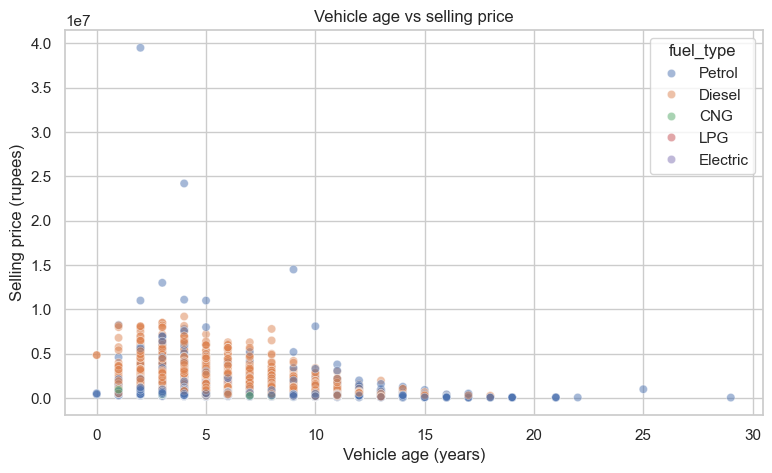

Correlation between age and price: -0.242


In [4]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x="vehicle_age", y="selling_price", hue="fuel_type",
                data=df, alpha=0.5)
plt.title("Vehicle age vs selling price")
plt.xlabel("Vehicle age (years)")
plt.ylabel("Selling price (rupees)")
plt.show()

print("Correlation between age and price:",
      round(df["vehicle_age"].corr(df["selling_price"]), 3))

### 📊 How to read this chart — Scatter plot

| What you are looking at | What it means |
|---|---|
| **Each dot** | One car. Its position shows both its age and its price at once |
| **The overall direction** | Sloping down left-to-right = as age rises, price falls |
| **How tightly packed** | Tight band = strong relationship. Wide cloud = weak one |
| **The colour (`hue`)** | A third variable, here fuel type — look for one colour clustering separately |
| **Dots far from the crowd** | Outliers again — an old car at a very high price is worth checking |
| **A curve rather than a line** | The relationship is not linear, so a straight-line model will underfit |

> **In one sentence:** Price falls steeply over the first few years and then flattens — which is a *curve*, not a straight line, and worth remembering when you fit a linear model to it.

### Example 4 — Bar plot vs count plot: the pair everyone confuses

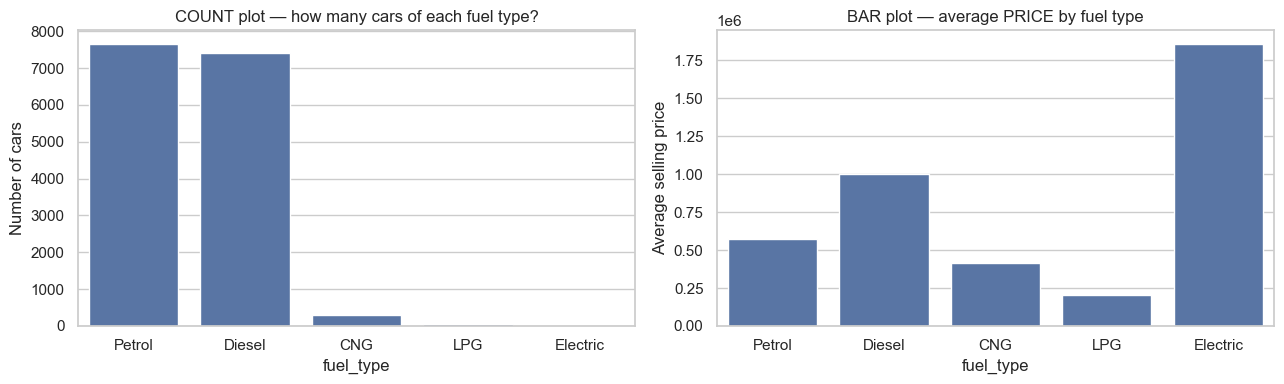

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# COUNT PLOT: how many ROWS in each category?
sns.countplot(x="fuel_type", data=df, ax=axes[0])
axes[0].set_title("COUNT plot — how many cars of each fuel type?")
axes[0].set_ylabel("Number of cars")

# BAR PLOT: the average of some OTHER column, per category
sns.barplot(x="fuel_type", y="selling_price", data=df, errorbar=None, ax=axes[1])
axes[1].set_title("BAR plot — average PRICE by fuel type")
axes[1].set_ylabel("Average selling price")

plt.tight_layout()
plt.show()

### 📊 How to read this chart — Count plot vs bar plot

| What you are looking at | What it means |
|---|---|
| **Count plot — bar height** | **How many rows** are in that category. Nothing else |
| **Bar plot — bar height** | The **average of another column** for that category |
| **A tall count bar** | That category is common in your data |
| **A tall bar-plot bar** | That category has a high average — but it might be based on only 3 rows |
| **Reading them together** | A category can be rare (short count bar) yet expensive (tall bar-plot bar) |

> **In one sentence:** The count plot tells you how *common* something is; the bar plot tells you how *big* it is — and you need both, because an impressive average built on five rows is not a finding.

> ⚠️ **The trap.** If one fuel type has the highest average price but only appears 12 times in 15,000 rows, that average is unreliable. **Always check the count plot before believing the bar plot.**

### Example 5 — Heatmap: which columns relate to which?

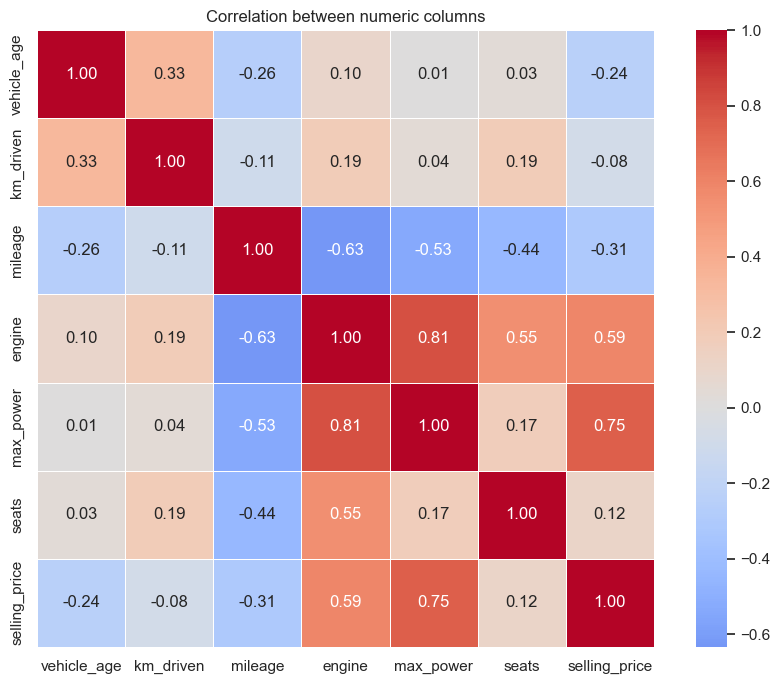

In [6]:
numeric = df.select_dtypes(include="number").drop(columns=["Unnamed: 0"], errors="ignore")

plt.figure(figsize=(9, 7))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation between numeric columns")
plt.tight_layout()
plt.show()

### 📊 How to read this chart — Correlation heatmap

| What you are looking at | What it means |
|---|---|
| **Each square** | How strongly two columns move together, from −1 to +1 |
| **Deep red (near +1)** | Strong positive — when one rises, the other rises |
| **Deep blue (near −1)** | Strong negative — when one rises, the other falls |
| **Pale / white (near 0)** | Little **linear** relationship. Not the same as 'unrelated' |
| **The diagonal, always 1.00** | Every column correlates perfectly with itself. Ignore it |
| **Two features deep red with each other** | They carry the same information — consider dropping one |
| **The target's row or column** | Read this one first: which features relate to what you are predicting |

> **In one sentence:** Read the target's row to find promising features, then scan the rest for pairs of features that duplicate each other.

> **Two warnings students routinely trip over.**
>
> 1. **A correlation of −0.3 is not 'weak' in real data.** In messy human data it is worth investigating. Do not discard a column because it scored 0.2.
> 2. **Correlation is not causation.** Ice cream sales correlate with drowning deaths — hot weather causes both.

## ✏️ Practice now — Visualisation

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** Draw a **histogram** of `km_driven` with 30 bins. Is it skewed? Which way?

**2.** Draw a **box plot** of `selling_price`. Roughly how many outlier dots do you see?

**3.** Draw a **scatter plot** of `km_driven` against `selling_price`. Describe the direction in one sentence.

**4.** Draw a **count plot** of `transmission_type`. Which is more common?

**5.** Draw a **bar plot** of average `selling_price` by `seller_type`. Then check the counts — is the top category reliable?

In [7]:
# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
# 1
sns.histplot(df["km_driven"], bins=30); plt.title("km_driven"); plt.show()
# Right-skewed: a long tail of very high-mileage cars.

# 2
sns.boxplot(x=df["selling_price"]); plt.title("selling_price"); plt.show()

# 3
sns.scatterplot(x="km_driven", y="selling_price", data=df, alpha=0.4); plt.show()
# Downward: more kilometres driven generally means a lower price.

# 4
sns.countplot(x="transmission_type", data=df); plt.show()
print(df["transmission_type"].value_counts())

# 5
sns.barplot(x="seller_type", y="selling_price", data=df, errorbar=None); plt.show()
print(df["seller_type"].value_counts())   # ALWAYS check the counts too
```

</details>

## 🧠 Quick quiz — Visualisation

Answer all five from memory. No scrolling back.

**Q1.** You want to know whether study hours relate to exam marks. Which chart, and why?

**Q2.** What is the difference between a count plot and a bar plot?

**Q3.** In a box plot, what do the dots beyond the whiskers mean, and what should you do about them?

**Q4.** Your histogram has a long tail to the right. What is that called, and why does it matter for modelling?

**Q5.** Two features show 0.95 correlation in a heatmap. What might you do, and why?

<details>
<summary><b>Answers</b></summary>

**A1.** A **scatter plot** — it is the only chart that shows two numeric variables at once, one per axis, so you can see the direction and tightness of the relationship.

**A2.** A **count plot** shows how many rows are in each category. A **bar plot** shows the average of some *other* column per category. A category can be rare yet have a high average.

**A3.** They are **outliers** — values more than 1.5 × IQR beyond the box. They are *candidates for investigation*, not errors. Check whether each is genuine (a taxi with 400,000 km) or a typo, and decide deliberately.

**A4.** **Right-skewed.** It matters because the mean is pulled above the median, and a linear model gets dragged towards the few extreme values, making it worse at predicting the many typical ones.

**A5.** Consider dropping one. They carry nearly the same information, so keeping both adds no signal but does add noise, slows training, and makes coefficients unstable in linear models.

</details>

## 🎯 Tasks — Visualisation

Longer work. Do these after the session, in your own time.

### Task 1: The four-panel story

Build a 2×2 figure for the **Titanic** dataset with four charts of your choosing.

For each panel write **one sentence saying what it tells you**, not what it is.

| ❌ Not an answer | ✅ An answer |
|---|---|
| "It shows the distribution of age" | "Most passengers were between 20 and 40, with a noticeable group of young children" |

Finish with a three-sentence summary of who was on that ship.

### Task 2: The misleading chart

Take any chart in this notebook and deliberately make it **mislead**, using only honest data. Try:

- changing the number of histogram bins
- cutting the y-axis so it does not start at zero
- plotting an average over a category with very few rows

Then write a paragraph on how a reader could have caught you.

**Why this matters:** you will read charts made by other people for the rest of your career.

---

# Concept 2 — Preprocessing

🧠 **Analogy: chopping before cooking.** No chef throws a whole unwashed onion into the pan. Peeling, washing and measuring take longer than the cooking itself — and **roughly 70% of real ML work is preprocessing.**

| Problem | Fix |
|---|---|
| Missing values | `dropna()`, `fillna()` |
| Text categories | `LabelEncoder`, `get_dummies()` |
| Very different scales | `StandardScaler`, `MinMaxScaler` |
| Extreme outliers | Cap or remove — deliberately |
| Unbalanced classes | `class_weight="balanced"` |

## 📘 Examples

### Example 1 — the full pipeline on twelve visible rows

In [8]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

small = pd.read_csv(BASE + "prepreprocessing/pre_data.csv")
print("STEP 0 — raw data (12 rows you can check by eye):")
print(small)

# STEP 1: remove the duplicate row
small = small.drop_duplicates().reset_index(drop=True)
print(f"\nSTEP 1 — after removing duplicates: {len(small)} rows")

# STEP 2: fill the missing Country with the most common value
most_common = small["Country"].mode()[0]
small["Country"] = small["Country"].fillna(most_common)
print(f"STEP 2 — filled missing Country with '{most_common}'")

# STEP 3: fill missing numbers with the MEDIAN, not the mean.
# The mean is dragged by the 1,500,000 outlier; the median is not.
for column in ["Age", "Salary"]:
    median_value, mean_value = small[column].median(), small[column].mean()
    small[column] = small[column].fillna(median_value)
    print(f"STEP 3 — {column}: used median {median_value:,.0f} "
          f"(the mean would have been {mean_value:,.0f})")

STEP 0 — raw data (12 rows you can check by eye):
    Country   Age     Salary Purchased
0    France  44.0    72000.0        No
1     Spain  27.0    48000.0       Yes
2       NaN  30.0    54000.0        No
3     Spain  38.0    61000.0        No
4   Germany  40.0        NaN       Yes
5    France  35.0    58000.0       Yes
6     Spain   NaN    52000.0        No
7    France  48.0    79000.0       Yes
8   Germany  50.0    83000.0        No
9    France  37.0    67000.0       Yes
10  Germany  50.0    83000.0        No
11    Spain  50.0  1500000.0        No

STEP 1 — after removing duplicates: 11 rows
STEP 2 — filled missing Country with 'France'
STEP 3 — Age: used median 39 (the mean would have been 40)
STEP 3 — Salary: used median 64,000 (the mean would have been 207,400)


In [9]:
# STEP 4: cap the outlier at the 95th percentile ("winsorising")
cap = small["Salary"].quantile(0.95)
small["Salary"] = small["Salary"].clip(upper=cap)
print(f"STEP 4 — capped salaries above {cap:,.0f}")

# STEP 5: text to numbers.
#   LabelEncoder  -> ordered categories, or tree models (No=0, Yes=1)
#   get_dummies   -> UNORDERED categories: one 0/1 column each.
#                    Numbering France=0, Germany=1, Spain=2 would tell a
#                    linear model that Spain is "more" than France. Nonsense.
small["Purchased"] = LabelEncoder().fit_transform(small["Purchased"])
small = pd.get_dummies(small, columns=["Country"], dtype=int)

# STEP 6: same 0-1 scale for Age and Salary
small[["Age", "Salary"]] = MinMaxScaler().fit_transform(small[["Age", "Salary"]])

print("\nSTEP 6 — fully preprocessed:")
print(small.round(3))
print("\nAny missing values left?", small.isnull().sum().sum())

STEP 4 — capped salaries above 791,500

STEP 6 — fully preprocessed:
      Age  Salary  Purchased  Country_France  Country_Germany  Country_Spain
0   0.739   0.032          0               1                0              0
1   0.000   0.000          1               0                0              1
2   0.130   0.008          0               1                0              0
3   0.478   0.017          0               0                0              1
4   0.565   0.022          1               0                1              0
5   0.348   0.013          1               1                0              0
6   0.522   0.005          0               0                0              1
7   0.913   0.042          1               1                0              0
8   1.000   0.047          0               0                1              0
9   0.435   0.026          1               1                0              0
10  1.000   1.000          0               0                0              1

Any mi

**✅ Look hard at the scaled Salary column.** Almost every value sits between 0.00 and 0.05, with one lonely 1.00.

Capping at the 95th percentile on eleven rows barely touched the outlier — it is still 10× everything else, so after scaling it flattens all the real variation into nothing.

> **A preprocessing step that runs without error is not the same as a preprocessing step that worked.** Always look at the output. (What would fix it here? A tighter cap, dropping the row, or scaling `log(Salary)` instead.)

### Example 2 — data leakage, and the rule that prevents it

🧠 **Analogy: studying with the answer key.**

Imagine practising for an exam with the answer key open beside you. You score 100% on every practice paper, walk into the real exam confident — and fail. Your practice score was meaningless because information from the answers leaked into your practice.

**That is data leakage.** The commonest way students cause it is scaling *before* splitting: `fit_transform` on the whole dataset learns the mean and range of the test rows, and bakes them into training.

**The rule: fit the scaler on the training data only.**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

loans = pd.read_csv(BASE + "loan_data_10k.csv").dropna().reset_index(drop=True)

CATEGORICAL = ["person_gender", "person_education", "person_home_ownership",
               "loan_intent", "previous_loan_defaults_on_file"]

for column in CATEGORICAL:
    encoder = LabelEncoder()
    loans[column] = encoder.fit_transform(loans[column])
    # LabelEncoder assigns 0,1,2... in ALPHABETICAL order. Print it, because
    # any app that serves this model must use the SAME mapping.
    print(f"{column}: {dict(zip(encoder.classes_, range(len(encoder.classes_))))}")

person_gender: {'female': 0, 'male': 1}
person_education: {'Associate': 0, 'Bachelor': 1, 'Doctorate': 2, 'High School': 3, 'Master': 4}
person_home_ownership: {'MORTGAGE': 0, 'OTHER': 1, 'OWN': 2, 'RENT': 3}
loan_intent: {'DEBTCONSOLIDATION': 0, 'EDUCATION': 1, 'HOMEIMPROVEMENT': 2, 'MEDICAL': 3, 'PERSONAL': 4, 'VENTURE': 5}
previous_loan_defaults_on_file: {'No': 0, 'Yes': 1}


In [11]:
X_loan = loans.drop(columns=["loan_status"])
y_loan = loans["loan_status"]

# SPLIT FIRST. Always.
# We name these *_loan so later sections cannot accidentally overwrite them -
# in a notebook you jump around, and reusing bare names like X_train across
# sections is a classic source of confusion.
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(
    X_loan, y_loan,
    test_size=0.2,        # hold back 20% the model never sees
    random_state=42,      # same split every run, so results are comparable
    stratify=y_loan,      # keep the class balance in both halves
)

# THEN scale: fit on train, transform both.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_loan)   # fit_transform on TRAIN
X_test_scaled = scaler.transform(X_test_loan)         # transform ONLY on test

print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)
print("Train mean after scaling (should be ~0):", X_train_scaled.mean().round(6))

Train: (7997, 13)  Test: (2000, 13)
Train mean after scaling (should be ~0): 0.0


### Example 3 — when to use which encoder

In [12]:
demo = pd.DataFrame({"size": ["Small", "Medium", "Large", "Medium"],
                     "city": ["Delhi", "Mumbai", "Chennai", "Delhi"]})
print("Original:\n", demo, "\n")

# 'size' HAS a natural order -> LabelEncoder is fine, but set the order
# yourself rather than letting it sort alphabetically.
order = {"Small": 0, "Medium": 1, "Large": 2}
demo["size_encoded"] = demo["size"].map(order)

# 'city' has NO order -> one column each, holding 0 or 1.
city_dummies = pd.get_dummies(demo["city"], prefix="city", dtype=int)

print("Encoded:\n", pd.concat([demo, city_dummies], axis=1))
print("\nNote: LabelEncoder on 'city' would say Chennai=0, Delhi=1, Mumbai=2,")
print("implying Mumbai > Delhi > Chennai. A linear model would believe that.")

Original:
      size     city
0   Small    Delhi
1  Medium   Mumbai
2   Large  Chennai
3  Medium    Delhi 

Encoded:
      size     city  size_encoded  city_Chennai  city_Delhi  city_Mumbai
0   Small    Delhi             0             0           1            0
1  Medium   Mumbai             1             0           0            1
2   Large  Chennai             2             1           0            0
3  Medium    Delhi             1             0           1            0

Note: LabelEncoder on 'city' would say Chennai=0, Delhi=1, Mumbai=2,
implying Mumbai > Delhi > Chennai. A linear model would believe that.


## ✏️ Practice now — Preprocessing

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** Load the Titanic dataset. How many missing values are in the `age` column?

**2.** Fill the missing `age` values with the **median** age. Confirm none remain.

**3.** The `embarked` column has a few missing values. Fill them with the **most common** value (`.mode()[0]`).

**4.** Convert the `sex` column to numbers using `LabelEncoder`, and **print the mapping**.

**5.** Split into train and test with `test_size=0.2`, `random_state=42`, `stratify=y` where `y` is `survived`. Print both shapes.

In [13]:
t = pd.read_csv(BASE + "classification/archive/titanic.csv")

# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
t = pd.read_csv(BASE + "classification/archive/titanic.csv")

# 1
print("missing age:", t["age"].isnull().sum())

# 2
t["age"] = t["age"].fillna(t["age"].median())
print("after fill:", t["age"].isnull().sum())

# 3
t["embarked"] = t["embarked"].fillna(t["embarked"].mode()[0])

# 4
enc = LabelEncoder()
t["sex"] = enc.fit_transform(t["sex"])
print("mapping:", dict(zip(enc.classes_, range(len(enc.classes_)))))

# 5
t = t.dropna()
Xt = t.drop(columns=["survived"]).select_dtypes(include="number")
yt = t["survived"]
Xtr, Xte, ytr, yte = train_test_split(Xt, yt, test_size=0.2,
                                      random_state=42, stratify=yt)
print(Xtr.shape, Xte.shape)
```

</details>

## 🧠 Quick quiz — Preprocessing

Answer all five from memory. No scrolling back.

**Q1.** Why must the scaler be fitted on the training set only?

**Q2.** When would you use `get_dummies` instead of `LabelEncoder`?

**Q3.** Why fill missing numbers with the median rather than the mean?

**Q4.** What does `stratify=y` do in `train_test_split`, and when do you need it?

**Q5.** Your preprocessing ran with no errors. Is it correct?

<details>
<summary><b>Answers</b></summary>

**A1.** Fitting on everything lets the test set's mean and range leak into training. Your test score becomes inflated and meaningless — you were studying with the answer key. This is **data leakage**, the most common serious beginner error.

**A2.** When the categories have **no natural order** (Delhi, Mumbai, Chennai) and you are using a model that reads numbers as magnitudes, such as linear or logistic regression. LabelEncoder would imply Mumbai > Delhi, which is meaningless.

**A3.** The mean is dragged by extreme values. In the 12-row example, one salary of 1,500,000 pushed the mean to 196,091 while the median stayed at 67,000. The median is not affected by that one value.

**A4.** It keeps the same class proportions in both the train and test sets. You need it for classification, especially with imbalanced classes — otherwise your test set might contain almost none of the minority class.

**A5.** Not necessarily. In the example above, capping the outlier ran fine but left it 10× everything else, so scaling flattened all the real variation. **Code that runs is not code that worked** — always look at the output.

</details>

## 🎯 Tasks — Preprocessing

Longer work. Do these after the session, in your own time.

### Task 1: Preprocess a messy dataset end to end

Take `datasets/classification/heart_failure_raw.csv` and write a complete, commented preprocessing pipeline.

For **every** decision, add a comment saying why you chose it:
- which missing-value strategy per column, and why
- which encoder per categorical column, and why
- whether to scale, and which scaler
- how you handled any outliers

**Print the data after every step.** Finish by confirming: no missing values, all columns numeric, train and test split correctly.

### Task 2: Cause data leakage on purpose

Deliberately build a leaky pipeline: scale the whole dataset **before** splitting, then train and report the test score.

Then build it correctly and report again.

Write down both numbers and the difference. **Being able to recognise the symptom — a suspiciously high test score — is worth more than memorising the rule.**

---

# Concept 3 — Regression: predicting a number

🧠 **Analogy: the straight road through scattered houses.**

Picture a scatter of dots — each dot is one person: years of experience across, salary up. Lay a ruler on the page and slide it until it sits as fairly as possible through the middle of the cloud.

**That line is linear regression.** The whole algorithm is: find the line where the total distance to all the dots is smallest.

```text
Salary  =  slope × Experience  +  intercept
           ↑                      ↑
    "each extra year         "what you'd earn
     is worth this much"      with zero years"
```

The model is **those two numbers**. Nothing more.

### ✏️ Before you run anything — Activity: beat the model

Look at these five real rows:

```text
Experience   Salary
   5.0       90,000
   3.0       65,000
  15.0      150,000
   7.0       60,000
  20.0      200,000
```

On paper: roughly how much is **one extra year** worth? Using your number, what would you predict for **5.5 years**?

**Write it down and commit before you see the model's answer.**

## 📘 Examples

### Example 1 — fit a line and read its equation

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

salary = pd.read_csv(BASE + "regression/salary_data.csv")
# This dataset has a few missing values and LinearRegression cannot handle NaN.
salary = salary.dropna().reset_index(drop=True)

# X must be 2-D (a table), y is 1-D (one column).
# That is why X uses DOUBLE brackets and y uses single.
X_salary = salary[["Experience"]]
y_salary = salary["Salary"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_salary, y_salary, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_tr, y_tr)          # this is where learning happens

print(f"Learned: Salary = {model.coef_[0]:,.0f} x Experience + {model.intercept_:,.0f}")
print(f"\nPrediction for 5.5 years: "
      f"{model.predict(pd.DataFrame({'Experience': [5.5]}))[0]:,.0f}")
print("How close was your paper estimate?")

Learned: Salary = 6,823 x Experience + 31,521

Prediction for 5.5 years: 69,045
How close was your paper estimate?


### Example 2 — see the line against the data

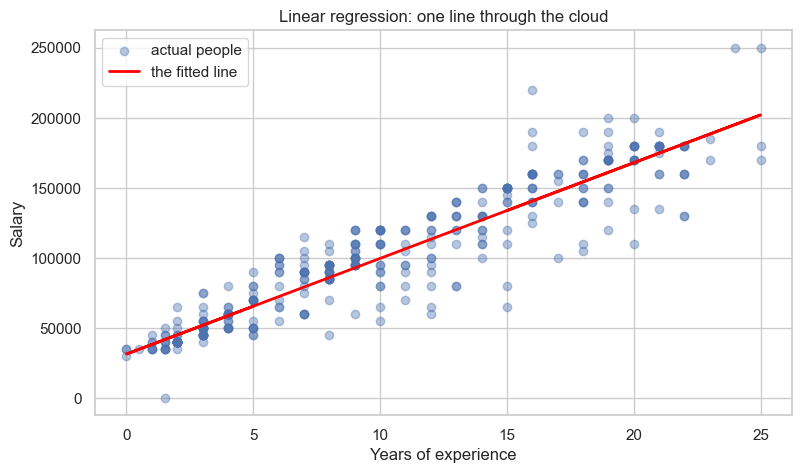

In [15]:
plt.figure(figsize=(9, 5))
plt.scatter(X_salary, y_salary, alpha=0.4, label="actual people")
plt.plot(X_salary, model.predict(X_salary), color="red", linewidth=2,
         label="the fitted line")
plt.xlabel("Years of experience")
plt.ylabel("Salary")
plt.title("Linear regression: one line through the cloud")
plt.legend()
plt.show()

### 📊 How to read this chart — Regression line plot

| What you are looking at | What it means |
|---|---|
| **The blue dots** | Real people from the data — the truth the model is trying to match |
| **The red line** | The model. Every prediction it will ever make lies exactly on this line |
| **The line's slope** | How much salary rises per extra year — the `coef_` value |
| **Where the line meets the y-axis** | The `intercept_` — predicted salary at zero experience |
| **A dot far above the line** | This person earns much more than experience alone explains |
| **A dot far below the line** | This person earns less than expected — the model cannot say why |
| **How tightly dots hug the line** | Tight = high R². Wide scatter = low R² |

> **In one sentence:** The line captures the general trend, and the vertical distance from each dot to the line is the error the model could not remove — which is exactly what R² measures.

### Example 3 — evaluate on data the model has never seen

In [16]:
y_pred = model.predict(X_te)

mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
r2 = r2_score(y_te, y_pred)

print(f"MAE : {mae:>10,.2f}")
print(f"RMSE: {rmse:>10,.2f}")
print(f"R2  : {r2:>10.4f}")

# ALWAYS turn the numbers into a sentence.
print(f"\nIn plain English:")
print(f"  The model is typically off by about {mae:,.0f}, which is "
      f"{100 * mae / y_salary.mean():.0f}% of the average salary.")
print(f"  Experience explains about {r2:.0%} of the variation in salary.")

MAE :  12,094.17
RMSE:  15,551.04
R2  :     0.8991

In plain English:
  The model is typically off by about 12,094, which is 12% of the average salary.
  Experience explains about 90% of the variation in salary.


### 📊 How to read regression metrics

| Metric | The question it answers | Good value | Watch out for |
|---|---|---|---|
| **MAE** | On average, how far off am I? Same unit as the target | As low as possible | Meaningless without context — always express it as a % of the average |
| **RMSE** | Like MAE, but punishes **large** mistakes much more heavily | As low as possible | RMSE much bigger than MAE means a few big misses |
| **R²** | What fraction of the variation did I explain? | Closer to 1 | See below |

### 🧠 What R² actually measures

Suppose you had to guess everyone's salary with **no information at all**. Your best strategy is to guess the average every time. Call that total wrongness 100%.

Now you are told each person's years of experience. **R² is the fraction of that original wrongness you removed.**

| R² | Meaning |
|---|---|
| **0.90** | You removed 90% of the guessing error |
| **0.30** | Experience matters, but something bigger is going on that you are not measuring |
| **0.00** | Knowing experience helped you not at all |
| **below 0** | You did **worse** than guessing the average. Something is broken |

> **Report it as a sentence.** *"Years of experience explains about 90% of the variation in salary"* — not "R2: 0.8991".

## ✏️ Practice now — Regression

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** Load `regression/advertising.csv`. Fit a linear regression predicting `Sales` from `TV` alone. Print the equation.

**2.** Report MAE, RMSE and R² on a held-out test set. Write one sentence explaining the R².

**3.** Now fit using `TV`, `Radio` **and** `Newspaper`. Did R² improve?

**4.** Print the three coefficients. Which advertising channel gives the most sales per unit spent?

**5.** Predict `Sales` for a campaign spending TV=150, Radio=30, Newspaper=10.

In [17]:
ad = pd.read_csv(BASE + "regression/advertising.csv").dropna()

# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
ad = pd.read_csv(BASE + "regression/advertising.csv").dropna()

# 1
X1, y1 = ad[["TV"]], ad["Sales"]
Xtr, Xte, ytr, yte = train_test_split(X1, y1, test_size=0.2, random_state=42)
m1 = LinearRegression().fit(Xtr, ytr)
print(f"Sales = {m1.coef_[0]:.4f} * TV + {m1.intercept_:.4f}")

# 2
p1 = m1.predict(Xte)
print("MAE", round(mean_absolute_error(yte, p1), 3),
      "RMSE", round(np.sqrt(mean_squared_error(yte, p1)), 3),
      "R2", round(r2_score(yte, p1), 4))
# TV spend alone explains about 60-65% of the variation in sales.

# 3
X3 = ad[["TV", "Radio", "Newspaper"]]
Xtr3, Xte3, ytr3, yte3 = train_test_split(X3, y1, test_size=0.2, random_state=42)
m3 = LinearRegression().fit(Xtr3, ytr3)
print("R2 with all three:", round(r2_score(yte3, m3.predict(Xte3)), 4))

# 4
print(dict(zip(X3.columns, m3.coef_.round(4))))   # Radio has the largest effect

# 5
print(m3.predict(pd.DataFrame({"TV": [150], "Radio": [30], "Newspaper": [10]})))
```

</details>

## 🧠 Quick quiz — Regression

Answer all five from memory. No scrolling back.

**Q1.** Why does `X` use double brackets `df[["Experience"]]` but `y` uses single?

**Q2.** Your model has MAE = 12,000. Is that good?

**Q3.** RMSE is much larger than MAE. What does that tell you?

**Q4.** What does R² = 0 mean? What would a negative R² mean?

**Q5.** Your R² is 0.40 and your partner says "that's terrible, let's use a neural network". What do you say?

<details>
<summary><b>Answers</b></summary>

**A1.** `X` must be 2-D — a table of features, even if there is only one. `y` is 1-D — a single column of answers. Double brackets return a DataFrame; single brackets return a Series.

**A2.** You cannot say without context. On salaries averaging 80,000 it is a 15% typical error, which may be acceptable. On salaries averaging 20,000 it would be useless. **Always express MAE as a proportion of the target's scale.**

**A3.** RMSE squares the errors before averaging, so large mistakes count far more. RMSE ≫ MAE means a few predictions are badly wrong, even though most are fine. Go and look at those rows.

**A4.** R² = 0 means the model is no better than always predicting the average. **Negative** means it is *worse* than that — which signals something broken: leaked features, a bad split, or a model fitted on the wrong target.

**A5.** 0.40 may be fine — in human-behaviour data it is often the honest ceiling. Before changing the algorithm, try better features, check for outliers, and look for a non-linear relationship in a scatter plot. **Changing model type is usually the least effective fix.**

</details>

## 🎯 Tasks — Regression

Longer work. Do these after the session, in your own time.

### Task 1: Predict used car prices

Using the cardekho dataset, build the best regression model you can for `selling_price`.

- Start with one feature, then add more, recording R² each time
- Encode the categorical columns properly
- Report MAE, RMSE and R², each with a plain-English sentence
- **Plot predicted vs actual.** A perfect model would put every dot on the diagonal — how far off is yours?
- Write two sentences on where your model fails worst, and why you think that is

### Task 2: The extrapolation trap

Fit the salary model, then ask it to predict for **50 years** and **200 years** of experience.

1. What does it return? Is it plausible?
2. Why does the model give a confident answer to an absurd question?
3. Add a guard to your code that warns when the input falls outside the training range.

**The lesson:** a model is only trustworthy inside the range it was trained on. Confidence is not correctness.

---

# Concept 4 — Classification: predicting a category

🧠 **Analogy: sorting the laundry.**

Regression asks *how much*. Classification asks *which pile*.

You already sort laundry into whites, colours and delicates without consciously applying a rule. You look at a garment, weigh up several clues, and it goes in a pile. A classifier does exactly that: takes several clues (features) and puts the row in a pile (class).

The extra thing a classifier gives you is **a confidence number** — not just "colours" but "colours, 87% confident". That is `predict_proba()`, and it is often more useful than the label.

## 📘 Examples

### Example 1 — always compute the baseline first

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# DummyClassifier always guesses the most common class. It learns NOTHING.
# If your real model cannot clearly beat it, your model learned nothing either.
models = {
    "Baseline (always majority)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

print(f"{'Model':<28}{'accuracy':>10}{'precision':>11}{'recall':>9}{'f1':>9}")
print("-" * 67)
for name, clf in models.items():
    clf.fit(X_train_loan, y_train_loan)
    p = clf.predict(X_test_loan)
    print(f"{name:<28}"
          f"{accuracy_score(y_test_loan, p):>10.4f}"
          f"{precision_score(y_test_loan, p, zero_division=0):>11.4f}"
          f"{recall_score(y_test_loan, p, zero_division=0):>9.4f}"
          f"{f1_score(y_test_loan, p, zero_division=0):>9.4f}")

Model                         accuracy  precision   recall       f1
-------------------------------------------------------------------
Baseline (always majority)      0.5000     0.0000   0.0000   0.0000


/Users/ahk/miniconda/envs/genai/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression             0.8640     0.8268   0.9210   0.8713


Random Forest                   0.8910     0.8710   0.9180   0.8939


**✅ Look at the baseline row.** It scores 50% accuracy and **0.0 recall** — it never identifies a single approved loan.

**That is what "learned nothing" looks like in numbers.** Always compute a baseline: it costs three lines and tells you whether your real model is doing anything at all.

### Example 2 — the confusion matrix

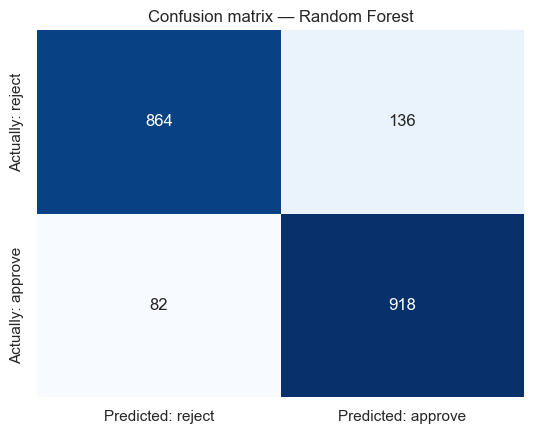

True negatives    864   correctly said 'reject'
False positives   136   said 'approve', was wrong   <- FALSE ALARM
False negatives    82   said 'reject', was wrong    <- A MISS
True positives    918   correctly said 'approve'


In [19]:
forest = RandomForestClassifier(n_estimators=200, random_state=42)
forest.fit(X_train_loan, y_train_loan)
y_pred_loan = forest.predict(X_test_loan)

matrix = confusion_matrix(y_test_loan, y_pred_loan)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted: reject", "Predicted: approve"],
            yticklabels=["Actually: reject", "Actually: approve"])
plt.title("Confusion matrix — Random Forest")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = matrix.ravel()
print(f"True negatives  {tn:>5}   correctly said 'reject'")
print(f"False positives {fp:>5}   said 'approve', was wrong   <- FALSE ALARM")
print(f"False negatives {fn:>5}   said 'reject', was wrong    <- A MISS")
print(f"True positives  {tp:>5}   correctly said 'approve'")

### 📊 How to read this chart — Confusion matrix

| What you are looking at | What it means |
|---|---|
| **Rows** | What was **actually** true |
| **Columns** | What the model **predicted** |
| **Top-left (TN)** | Correctly said no. ✅ Good |
| **Bottom-right (TP)** | Correctly said yes. ✅ Good |
| **Top-right (FP)** | Said yes when it was no — a **false alarm** |
| **Bottom-left (FN)** | Said no when it was yes — a **miss** |
| **The diagonal** | Everything the model got right. You want this dark |
| **Off-diagonal** | Everything it got wrong — and the two corners are wrong in *completely different ways* |

> **In one sentence:** Two boxes are good news and two are bad — but a false alarm annoys someone, while a miss can be catastrophic, so which corner you care about depends entirely on the problem.

🧠 **Analogy: the fire-alarm report.**

|  | Alarm stayed quiet | Alarm went off |
|---|---|---|
| **No fire** | ✅ Correct silence (TN) | 🔔 False alarm (FP) |
| **There was a fire** | 💀 Missed fire (FN) | ✅ Caught it (TP) |

A false alarm annoys people. **A missed fire kills them.** That is why alarms go off when you burn toast — they are tuned for recall.

### Example 3 — confidence, not just the label

First five predictions with their confidence:
  predicted approve  confidence 55.5%
  predicted approve  confidence 83.0%
  predicted reject   confidence 74.0%
  predicted approve  confidence 99.5%
  predicted reject   confidence 74.0%

How confident is the model overall?
  above 90%:  1207 predictions
  70% - 90%:   387
  below 70%:   406  <- a human should check these


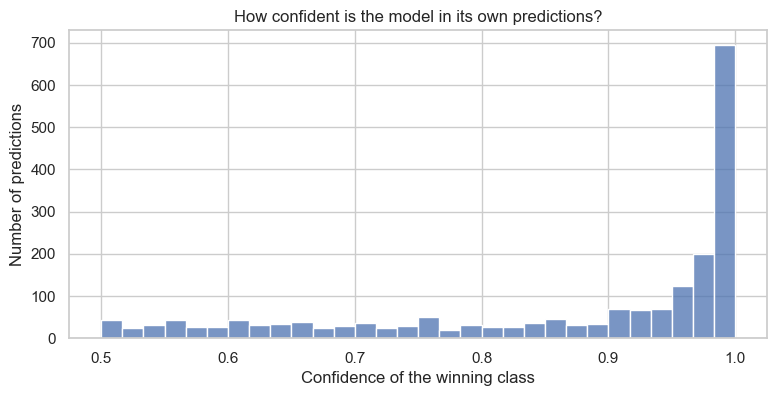

In [20]:
# predict_proba gives the probability of each class, not just the winner.
probabilities = forest.predict_proba(X_test_loan)
confidence = probabilities.max(axis=1)

print("First five predictions with their confidence:")
for i in range(5):
    label = "approve" if y_pred_loan[i] == 1 else "reject"
    print(f"  predicted {label:<8} confidence {confidence[i]:.1%}")

print(f"\nHow confident is the model overall?")
print(f"  above 90%: {(confidence > 0.90).sum():>5} predictions")
print(f"  70% - 90%: {((confidence > 0.70) & (confidence <= 0.90)).sum():>5}")
print(f"  below 70%: {(confidence <= 0.70).sum():>5}  <- a human should check these")

plt.figure(figsize=(9, 4))
sns.histplot(confidence, bins=30)
plt.title("How confident is the model in its own predictions?")
plt.xlabel("Confidence of the winning class")
plt.ylabel("Number of predictions")
plt.show()

### 📊 How to read this chart — Confidence distribution

| What you are looking at | What it means |
|---|---|
| **The x-axis** | How sure the model was, from 0.5 (a coin flip) to 1.0 (certain) |
| **Bars near 1.0** | Confident predictions. Usually, but not always, the correct ones |
| **Bars near 0.5** | The model is guessing. These rows sit near the decision boundary |
| **A big pile near 1.0** | The model finds most cases easy — or it is overconfident |
| **A big pile near 0.5** | The model is struggling. More features or a better model needed |

> **In one sentence:** This chart tells you *which* predictions to trust — and in a real system, everything below about 70% would be routed to a human instead of acted on automatically.

## ✏️ Practice now — Classification

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** Train a `DummyClassifier` on the Titanic data (predicting `survived`). What accuracy does it get?

**2.** Train a `LogisticRegression` on the same data. Does it beat the baseline?

**3.** Print the full `classification_report`. Which class does the model handle worse?

**4.** Print the confusion matrix and say, in words, what each of the four numbers means for a passenger.

**5.** Use `predict_proba` to find how many test passengers the model predicted with **less than 60% confidence**.

In [21]:
t = pd.read_csv(BASE + "classification/archive/titanic.csv").dropna().reset_index(drop=True)

# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
t = pd.read_csv(BASE + "classification/archive/titanic.csv").dropna().reset_index(drop=True)
for c in t.select_dtypes(include="object").columns:
    t[c] = LabelEncoder().fit_transform(t[c])
Xt, yt = t.drop(columns=["survived"]), t["survived"]
Xtr, Xte, ytr, yte = train_test_split(Xt, yt, test_size=0.2, random_state=42, stratify=yt)

# 1
d = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
print("baseline:", round(d.score(Xte, yte), 4))

# 2
lr = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
print("logistic:", round(lr.score(Xte, yte), 4))

# 3
print(classification_report(yte, lr.predict(Xte)))

# 4
print(confusion_matrix(yte, lr.predict(Xte)))
# TN: correctly predicted died. FP: predicted survived but died.
# FN: predicted died but survived. TP: correctly predicted survived.

# 5
conf = lr.predict_proba(Xte).max(axis=1)
print("below 60% confidence:", (conf < 0.60).sum())
```

</details>

## 🧠 Quick quiz — Classification

Answer all five from memory. No scrolling back.

**Q1.** What is a `DummyClassifier` for, and why should you always run one?

**Q2.** In a confusion matrix, which corner is a 'miss' and which is a 'false alarm'?

**Q3.** What does `predict_proba` give you that `predict` does not, and why does it matter?

**Q4.** A model predicts 'approved' with 55% confidence. Would you act on it automatically?

**Q5.** Why is classification's 'which pile' question easier to evaluate than clustering's?

<details>
<summary><b>Answers</b></summary>

**A1.** It always predicts the most common class, so it learns nothing. It gives you the score any model must beat. Without it you cannot tell whether 89% accuracy is impressive or trivial.

**A2.** **False negative** (bottom-left) is a miss — it was yes and you said no. **False positive** (top-right) is a false alarm — it was no and you said yes.

**A3.** The probability of each class rather than just the winning label. It matters because 'approve at 51%' and 'approve at 99%' are completely different claims, and an interface that hides that difference is lying by omission.

**A4.** No. 55% is barely better than a coin flip. In a real system, low-confidence predictions should be routed to a human rather than acted on. The confidence histogram tells you how many such cases you have.

**A5.** Classification has labelled answers to compare against, so you can compute accuracy, precision and recall. Clustering has no answer key at all, so it has no accuracy score — you judge it by whether the groups are useful.

</details>

## 🎯 Tasks — Classification

Longer work. Do these after the session, in your own time.

### Task 1: Heart failure: recall matters

Build a classifier on `classification/heart_failure_raw.csv` predicting `DEATH_EVENT`.

1. Compute the baseline first
2. Train at least three models
3. Report accuracy, precision, recall and F1 for each
4. Draw the confusion matrix for your best model
5. **Answer explicitly: which metric matters most here, and why?**
6. Now re-rank your models by that metric. Did the winner change?

> A model that misses a high-risk patient is doing something very different from one that raises a false alarm. Your report must say which you optimised for.

### Task 2: The threshold dial

The default decision cut-off is 0.5. Using `predict_proba`:

1. Compute precision and recall at thresholds 0.1, 0.3, 0.5, 0.7 and 0.9
2. Plot both against the threshold on one chart
3. Describe in words what happens to each as the threshold rises
4. **For a cancer screening tool, which threshold would you ship, and what does that cost you?**

```python
probabilities = model.predict_proba(X_test)[:, 1]
y_pred = (probabilities >= threshold).astype(int)
```

You will see precision rise and recall fall. **There is no setting that improves both** — that is the whole point.

---

# Concept 5 — Reading metrics honestly

🧠 **Analogy: precision and recall are a fishing net.**

You are fishing for tuna in a lake that also contains other fish.

- **Precision** — you haul in the net. Of everything *in your net*, how much is actually tuna?
- **Recall** — of all the tuna *in the entire lake*, how much did you catch?

Now notice the tension:

- A tiny, very selective net → almost everything you catch is tuna (**high precision**) but you miss most of the lake (**low recall**)
- A giant dragnet → you catch every tuna (**high recall**) but also boots and weeds (**low precision**)

**You cannot maximise both.** Where you choose to sit depends entirely on what each mistake costs.

## 📘 Examples

### Example 1 — build the useless 99% model

In [22]:
# Do not take the warning on trust. Build it yourself.
# 1,000 transactions. Only 10 are fraud.

y_true = np.array([0] * 990 + [1] * 10)
X_dummy = np.zeros((1000, 1))          # the features do not even matter

lazy = DummyClassifier(strategy="most_frequent").fit(X_dummy, y_true)
y_lazy = lazy.predict(X_dummy)

print("Accuracy :", accuracy_score(y_true, y_lazy))
print("Precision:", precision_score(y_true, y_lazy, zero_division=0))
print("Recall   :", recall_score(y_true, y_lazy, zero_division=0))
print()
print("Fraud cases caught:", int(((y_lazy == 1) & (y_true == 1)).sum()), "out of 10")
print("\n99% accuracy. Zero frauds caught. This model is worthless.")

Accuracy : 0.99
Precision: 0.0
Recall   : 0.0

Fraud cases caught: 0 out of 10

99% accuracy. Zero frauds caught. This model is worthless.


> **If you showed only the accuracy in a presentation, this would look excellent.**
>
> That is why you always print the full classification report — never accuracy alone.

### Example 2 — which metric for which problem

In [23]:
scenarios = pd.DataFrame([
    ("Cancer screening",  "Healthy person gets a scan", "Cancer missed entirely",  "Recall"),
    ("Spam filter",       "Real email binned",          "Spam reaches inbox",      "Precision"),
    ("Fraud detection",   "Genuine purchase blocked",   "Fraud goes through",      "Recall (usually)"),
    ("Loan approval",     "Good applicant rejected",    "Bad loan approved",       "Depends who you ask"),
    ("Fire alarm",        "Alarm with no fire",         "Fire with no alarm",      "Recall"),
    ("Court evidence",    "Innocent flagged",           "Guilty missed",           "Precision"),
], columns=["System", "False alarm costs", "A miss costs", "Optimise for"])

scenarios

,System,False alarm costs,A miss costs,Optimise for
0,Cancer screening,Healthy person gets a scan,Cancer missed entirely,Recall
1,Spam filter,Real email binned,Spam reaches inbox,Precision
2,Fraud detection,Genuine purchase blocked,Fraud goes through,Recall (usually)
3,Loan approval,Good applicant rejected,Bad loan approved,Depends who you ask
4,Fire alarm,Alarm with no fire,Fire with no alarm,Recall
5,Court evidence,Innocent flagged,Guilty missed,Precision


**The row to argue about is 'Loan approval'.** The bank says a bad loan is worse, so it wants precision. The rejected applicant strongly disagrees and wants recall.

> **"Which metric should I use?" is not a maths question.** It is a question about **what it costs to be wrong**, and to *whom* — and you cannot answer it from the data alone.

### Example 3 — the classification report, line by line

In [24]:
print(classification_report(y_test_loan, y_pred_loan,
                            target_names=["rejected", "approved"]))

              precision    recall  f1-score   support

    rejected       0.91      0.86      0.89      1000
    approved       0.87      0.92      0.89      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



### 📊 How to read a classification report

| Column | What it means for that row's class |
|---|---|
| **precision** | Of everything I *labelled* this class, what fraction really was? |
| **recall** | Of everything that really *is* this class, what fraction did I find? |
| **f1-score** | The balance of the two. Use it when you care about both |
| **support** | How many rows of this class were in the test set |

| Row | What it means |
|---|---|
| **Each class row** | The metrics for that one class, judged on its own |
| **accuracy** | Overall fraction correct. **Ignore it when classes are imbalanced** |
| **macro avg** | Plain average across classes — treats a rare class as equally important |
| **weighted avg** | Average weighted by `support` — dominated by the common class |

**The checks to make, in order:**

1. **Look at `support` first.** If one class has 50 rows and the other 5,000, ignore `accuracy` entirely.
2. **Read the minority class's row.** That is where models fail, and where accuracy hides it.
3. **Compare `macro avg` with `weighted avg`.** A big gap means the model is much better on the common class.

> **In one sentence:** the accuracy line is the one people quote and the one that misleads — read the minority class row instead.

## ✏️ Practice now — Metrics

Five short exercises. Do them **before** moving on — this is where the learning happens.

**1.** A fraud model has 1,000 transactions, 10 of them fraud, and catches 4. It flags 6 legitimate ones. Build the confusion matrix by hand.

**2.** From those numbers, compute precision and recall for the fraud class **on paper**, then check with `sklearn`.

**3.** A model scores accuracy 0.97, precision 0.30, recall 0.85. Describe in one sentence what kind of model this is.

**4.** For a **spam filter**, would you rather have precision 0.99 / recall 0.70, or precision 0.70 / recall 0.99? Justify it.

**5.** Compute the `macro avg` F1 by hand from a two-class report, and confirm it matches sklearn.

In [25]:
# 1.


# 2.


# 3.


# 4.


# 5.

<details>
<summary><b>Solutions — open only after you have tried all five</b></summary>

```python
# 1  TP=4, FN=6 (missed frauds), FP=6, TN=984
import numpy as np
y_true = np.array([1]*10 + [0]*990)
y_pred = np.array([1]*4 + [0]*6 + [1]*6 + [0]*984)
print(confusion_matrix(y_true, y_pred))

# 2  precision = TP/(TP+FP) = 4/10 = 0.40
#    recall    = TP/(TP+FN) = 4/10 = 0.40
print("precision", precision_score(y_true, y_pred),
      "recall", recall_score(y_true, y_pred))

# 3  It flags far too many false positives (low precision) but catches most
#    real cases (high recall). It is tuned for recall - sensible for screening,
#    annoying for a spam filter.

# 4  precision 0.99 / recall 0.70. A lost job offer is far worse than one spam
#    email you delete, so false alarms must be rare even if some spam gets through.

# 5  macro avg F1 = (F1_class0 + F1_class1) / 2, unweighted by support.
print(classification_report(y_true, y_pred))
```

</details>

## 🧠 Quick quiz — Metrics

Answer all five from memory. No scrolling back.

**Q1.** A fraud model reports 99.2% accuracy. Give two reasons it might be worthless.

**Q2.** Define precision and recall using the fishing-net analogy.

**Q3.** Why can you not maximise both precision and recall?

**Q4.** In a classification report, why look at `support` before `accuracy`?

**Q5.** `macro avg` F1 is 0.62 but `weighted avg` F1 is 0.91. What does that gap tell you?

<details>
<summary><b>Answers</b></summary>

**A1.** **1. Class imbalance** — if 99% of transactions are legitimate, always predicting 'not fraud' scores 99% and catches nothing. **2. Data leakage** — a column like `investigation_opened` may have leaked in, so the model is reading the answer. Ask for the confusion matrix and the recall on the fraud class.

**A2.** **Precision:** of everything in your net, how much is the fish you wanted. **Recall:** of all the fish in the lake, how much you caught. A small selective net has high precision and low recall; a dragnet has the reverse.

**A3.** They trade off against each other. Making the model more willing to say 'yes' catches more true cases (recall up) but also more false alarms (precision down). Every classifier sits somewhere on that curve; you choose where.

**A4.** `support` tells you how many rows each class had. If one class has 50 and the other 5,000, accuracy is dominated by the common class and tells you almost nothing about whether the model works on the rare one — which is usually the one you care about.

**A5.** The model performs well on the common class and badly on the rare one. `weighted avg` is dominated by the common class, while `macro avg` treats both equally. **A big gap between them is the signature of a model that has quietly given up on the minority class.**

</details>

## 🎯 Tasks — Metrics

Longer work. Do these after the session, in your own time.

### Task 1: The metrics report

Take any classifier you have built and write a one-page report a **non-technical manager** could act on.

Requirements:
- No metric appears as a bare number — every one gets a sentence
- State explicitly which kind of mistake this model makes more often
- State what that would mean in practice for a real person affected by it
- Include the baseline for comparison
- End with a recommendation and **one thing you would want before deploying**

### Task 2: Build the metrics yourself

Without using sklearn's metric functions, write your own:

```python
def my_confusion_matrix(y_true, y_pred): ...
def my_precision(y_true, y_pred): ...
def my_recall(y_true, y_pred): ...
def my_f1(y_true, y_pred): ...
```

Check each against sklearn on a real prediction.

**Why:** metrics you have implemented once are metrics you will never misremember.

### Task 3: The 99% trap, in the wild

Find a real dataset in [`datasets/`](../../datasets/) with **imbalanced classes**.

1. Train a model and report its accuracy
2. Report the `DummyClassifier` accuracy
3. Compute how much of the model's score is just the imbalance
4. Report the metric that actually shows whether the model works
5. Write two sentences you would put in a report so nobody is misled

---
# ✅ Day 2 exit task

Complete the [ML practice exercise](https://github.com/tech4alltraining/aiml/blob/main/assessments/ml_ai_practice.md).

For **every** model you train, report accuracy **and** precision **and** recall — and write one sentence on which of the three matters most for that problem, and why.

In [26]:
# Your exit task working here.

---
## What next

| | |
|---|---|
| **Previous** | [Day 1 — Python, NumPy, Pandas](01_day1_python_data.ipynb) |
| **Next** | [Day 3 — Improving your model](03_day3_model_improvement.ipynb) |
| **Handbook** | [Day 2 chapter](../student-handbook.md#day-2--visualisation-preprocessing-and-supervised-learning) |
| **More practice** | [exercises-assignments.md](../exercises-assignments.md) |